
 ## 1. Carregar dados

In [1]:
import pandas as pd

In [2]:
# usamos df pois é a convenção, umas vez que essa tabela abaixo é um tipo de dado chamado dataframe na biblioteca pandas
df = pd.read_csv('https://raw.githubusercontent.com/cassiasamp/build_with_ai_ws/refs/heads/main/dados/dados_tratados.csv')

In [3]:
df.head(n=5)

,idade,sistolica,diastolica,glicose,temperatura,batimentos,risco
0,25,130,80,15.0,98.0,86,alto
1,35,140,90,13.0,98.0,70,alto
2,29,90,70,8.0,100.0,80,alto
3,30,140,85,7.0,98.0,70,alto
4,35,120,60,6.1,98.0,76,baixo


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   idade        1014 non-null   int64  
 1   sistolica    1014 non-null   int64  
 2   diastolica   1014 non-null   int64  
 3   glicose      1014 non-null   float64
 4   temperatura  1014 non-null   float64
 5   batimentos   1014 non-null   int64  
 6   risco        1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


## 2. Dividir entre características (X) e  rótulos (y)
X são os valores que iremos usar para prever e y o que queremos prever. É uma aprendizagem supervisionada e de classificação, pois o nosso y são 3 categorias distintas.

In [5]:
y = df['risco']

In [6]:
# dependendo do modelo que iremos usar (por exemplo, para modelos de árvores) não precisaríamos modificar o texto para valores numéricos, mas aqui iremos modificar para melhorar o processamento.
y.head(n=5)

,risco
0,alto
1,alto
2,alto
3,alto
4,baixo


In [7]:
# vamos ver os nomes dos valores únicos de y
y.unique()

array(['alto', 'baixo', 'medio'], dtype=object)

In [8]:
# e dependendo do modelo também, números maiores influenciam na importância que o modelo dá na predição, então é bom sempre checar isso também.
# vamos criar um dicionário para substituir os valores categóricos por numéricos (também há métodos do scikit learn que fazem isso em pre-processing)
y_dict = {'alto': 2, 'medio': 1, 'baixo': 0}
y = df['risco'].map(y_dict)

In [9]:
y.head(n=3)

,risco
0,2
1,2
2,2


In [10]:
# vamos remover o que queremos prever (y) do que iramos usar para prever (X)
X = df.drop(['risco'], axis=1)

In [11]:
X.head()

,idade,sistolica,diastolica,glicose,temperatura,batimentos
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76


## 3. Dividir dados entre treino e teste

In [12]:
import sklearn

In [13]:
from sklearn.model_selection import train_test_split
# aqui definimos um número como constante para que os nossos resultados sejam os mesmos, é uma semente aleatória
# ou seja, toda a vez que tiver algo pseudoaleatório o ponto de partida será esse número, tornando os resultados os mesmos
SEED = 42

In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [15]:
X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((811, 6), (203, 6), (811,), (203,))

Neste ponto, separamos os dados entre treino e teste, com 20% (0.2) dos dados que são 203 pontos para teste

## 4. Standardizar dados

Como os nossos dados têm medidas diferentes, precisamos deixá-los na mesma escala, para isso iremos estandardiza-los.

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
standardizador = StandardScaler()

In [18]:
# standardizamos o treino separadamente do teste, para não vazar informações para teste e no teste, usamos apenas o método transform, sem o fit para evitar isso também.
X_treino_st = standardizador.fit_transform(X_treino)
X_teste_st = standardizador.transform(X_teste)

In [19]:
X_treino_st

array([[ 0.01586892,  0.3596051 ,  0.26018219,  0.06867785,  1.65272892,
         0.19541766],
       [-0.50789785,  0.90037968, -0.46517963, -0.56360093, -0.50034961,
        -0.5310165 ],
       [ 0.16551657,  0.3596051 ,  0.98554401, -0.56360093, -0.50034961,
        -0.5310165 ],
       ...,
       [-0.95684079, -1.26271865, -0.97293291, -0.56360093,  1.65272892,
        -0.5310165 ],
       [ 2.63470278,  0.90037968,  0.26018219,  1.87518866, -0.50034961,
         1.40614125],
       [ 1.36269776,  1.44115426,  0.98554401,  1.87518866, -0.50034961,
         1.89043069]])

In [20]:
X_teste_st

array([[-0.0589549 ,  0.90037968, -0.46517963, -0.32273282, -0.50034961,
         0.43756238],
       [ 0.01586892,  1.44115426,  1.71090582,  1.87518866, -0.50034961,
        -0.5310165 ],
       [ 1.51234541,  1.44115426,  1.34822491,  2.47735893, -0.50034961,
        -1.7417401 ],
       ...,
       [ 2.26058366, -1.26271865, -0.82786054, -0.59370944, -0.50034961,
         0.31649002],
       [-0.65754549, -1.26271865, -1.19054145, -0.56360093, -0.50034961,
         1.40614125],
       [-0.3582502 ,  1.44115426,  1.71090582, -0.53048156, -0.50034961,
         0.67970709]])

## 5. Criar um modelo de base para compararmos com os nossos resultados

In [26]:
# iremos usar o classificador "bobo" do scikit learn que preve sempre a classe mais frequente de y
from sklearn.dummy import DummyClassifier

In [27]:
dc = DummyClassifier(strategy='most_frequent', random_state=SEED)
dc.fit(X_treino_st, y_treino)

DummyClassifier(random_state=42, strategy='most_frequent')

In [43]:
# aqui o score retorna a acurácia que é quanto o modelo acertou
# em treino
dc.score(X_treino_st, y_treino)

0.40197287299630086

In [44]:
# e em teste
dc.score(X_teste_st, y_teste)

0.39408866995073893

Repare que no quesito acertos, o nosso modelo foi super mal, tanto em treino quanto em teste.

## 6. Criar modelo
Agora iremos usar um modelo de árvore, que parece que irá funcionar bem pelo que vimos na exploração dos dados.
Para ver o "desenho" que algumas funções dos modelos (ou estimadores) de classificação fazem, acesse: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rfc = RandomForestClassifier(random_state=SEED)

In [35]:
rfc.fit(X_treino_st, y_treino)

RandomForestClassifier(random_state=42)

In [42]:
# acurácia de treino
rfc.score(X_treino_st, y_treino)

0.935881627620222

In [45]:
# acurácia de teste
rfc.score(X_teste_st, y_teste)

0.8078817733990148

Repare que a acurácia é bem mais alta com esse modelo.

In [46]:
# e é assim que ficam as predições, para cada linha, um valor de alto, medio ou baixo
rfc.predict(X_teste_st)

array([1, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 1, 1, 2, 1, 1, 2, 0, 0, 1, 1, 1,
       2, 2, 0, 1, 2, 1, 0, 0, 1, 2, 0, 1, 0, 2, 2, 1, 0, 2, 2, 0, 2, 2,
       0, 1, 2, 1, 0, 0, 1, 0, 0, 1, 1, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0, 2,
       1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       2, 1, 1, 2, 0, 2, 1, 0, 1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 2, 1, 0, 0, 2, 1, 2, 1, 0, 0, 1, 2, 2, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 2, 1, 0, 1, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 1, 0, 1, 2,
       1, 0, 0, 0, 2, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2,
       0, 1, 1, 1, 2])

Nesta etapa também podemos fazer uma triagem com diversos modelos de classificação diferentes, realizar algo chamado de busca de hiperparametros com validacao cruzada (grid search with cross validation) para entender quais são os melhores números para cada parâmetro do modelo e para que ele generalize ainda mais e usar as pipelines do scikit-learn para automatizar e organizar o fluxo. Essas são etapas mais avançadas e talvez para este modelo específico nem sejam necessárias, pois tudo indica que ele já está prevendo bem, sem sobre o sub ajuste. Veremos se as métricas confirmam isso.

## 7. Avaliar modelo

Nesta etapa conseguimos ver melhor algumas métricas além da acurácia que não nos diz muito, apenas mostra o que acertou - mas não onde o modelo errou ou o que pode ser melhorado.

In [39]:
# iremos gerar um reporte de classificacao e uma matriz de confusao
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
predicoes = rfc.predict(X_teste_st)

In [41]:
print(classification_report(y_teste, predicoes))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        80
           1       0.74      0.84      0.79        76
           2       0.87      0.85      0.86        47

    accuracy                           0.81       203
   macro avg       0.82      0.81      0.82       203
weighted avg       0.81      0.81      0.81       203



Aqui temos outras métricas como precisão, revocação, e f1. A precisão mostra quantos valores o modelo acertou, a revocação, quantos ele identificou, e o f1 é a média harmônica dos dois (1/ precisao ou revocação), pois ela considera a razão entre eles e minimiza o impacto de valores altos fora da curva na métrica.

Em todas as métricas, quanto mais próximo de 1 ou 100%, melhor. No entanto, um  modelo que gereraliza bem dados novos e será bom na vida real geralmente fica um pouco abaixo de 90% - caso o modelo fique acima disso, é importante verificar se não há alguma transformação incorreta dos dados (pois a realidade não é tão simples assim).

In [47]:
# a matriz de confusao nos diz quais classes foram identificadas corretas ou incorretamente
cf = confusion_matrix(y_teste, predicoes)

In [48]:
cf

array([[60, 17,  3],
       [ 9, 64,  3],
       [ 1,  6, 40]])

In [49]:
# usaremos seaborn para visualizar melhor
import seaborn as sns

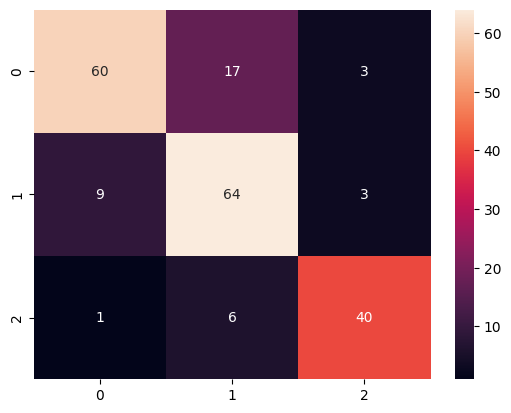

In [52]:
sns.heatmap(cf, annot=True);

Por exemplo, podemos ver que para a classe 0, que é risco baixo, 60 pontos foram identificados corretamente e o maior erro foram 17 pontos identificados como risco médio e 3 como risco alto. Analisando para todas as classes, podemos pensar como melhorar o modelo.

## 8. Salvar modelo
Para salvarmos o modelo iremos usar o pickle, que é meio um .zip versão modelos

In [ ]:
import pickle as pk

In [ ]:
# com .dump criamos o arquivo pkl
pk.dump(rfc, open('modelo_rfc.pkl', 'wb'))

In [ ]:
# com .load, podemos carregar o modelo e usá-lo, o que significa que não precisamos treiná-lo novamente
modelo = pk.load(open('modelo_rfc.pkl', 'rb'))

In [ ]:
modelo.predict(X_teste_st)

array([1, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 1, 1, 2, 1, 1, 2, 0, 0, 1, 1, 1,
       2, 2, 0, 1, 2, 1, 0, 0, 1, 2, 0, 1, 0, 2, 2, 1, 0, 2, 2, 0, 2, 2,
       0, 1, 2, 1, 0, 0, 1, 0, 0, 1, 1, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0, 2,
       1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       2, 1, 1, 2, 0, 2, 1, 0, 1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 2, 1, 0, 0, 2, 1, 2, 1, 0, 0, 1, 2, 2, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 2, 1, 0, 1, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 1, 0, 1, 2,
       1, 0, 0, 0, 2, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2,
       0, 1, 1, 1, 2])

In [ ]:
modelo.score(X_teste_st, y_teste)

0.8078817733990148